In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from datasets import load_dataset

ds = load_dataset("Prady06/customer-support-tickets")


In [ ]:
ds=ds['train'].to_pandas()

In [ ]:

ds.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,None,None,None
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,None,None,None,None


In [ ]:
ds.shape

(61765, 16)

In [ ]:
ds = ds[ds["language"] == "en"]

In [ ]:
ds.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,None,None,None
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,None,None,None,None
5,Feature Query,"Dear Customer Support,\n\nI hope this message ...",Thank you for your inquiry. Please specify whi...,Request,Technical Support,high,en,51.0,Feature,Product,Documentation,Feedback,None,None,None,None


In [ ]:
ds.shape

(28261, 16)

In [ ]:
a=ds[["subject","body","type","queue","priority"]]
a

,subject,body,type,queue,priority
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...",Incident,Technical Support,high
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Request,Returns and Exchanges,medium
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",Request,Billing and Payments,low
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Problem,Sales and Pre-Sales,medium
5,Feature Query,"Dear Customer Support,\n\nI hope this message ...",Request,Technical Support,high
...,...,...,...,...,...
61757,Guidelines for Securing Medical Data in OBS St...,Seeking details on securing medical data using...,Request,Technical Support,high
61758,None,Can you provide information on digital strateg...,Request,Billing and Payments,medium
61759,Support for Marketing Enhancements,Request for assistance in improving digital ma...,Change,Technical Support,high
61760,Assistance Needed for IFTTT Docker Integration,I am facing integration problems with IFTTT Do...,Problem,Technical Support,low


In [ ]:

a.value_counts(['priority'])

,count
priority,
medium,11570
high,10917
low,5774


In [ ]:
a.value_counts(['queue'])

,count
queue,
Technical Support,8149
Product Support,5305
Customer Service,4269
IT Support,3333
Billing and Payments,2897
Returns and Exchanges,1402
Service Outages and Maintenance,1106
Sales and Pre-Sales,843
Human Resources,553


In [ ]:
a["issue_description"] = (
    a["subject"].fillna('') + " " +
    a["body"].fillna('')
)

/tmp/ipykernel_6342/4150581410.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a["issue_description"] = (


In [ ]:
a

,subject,body,type,queue,priority,issue_description
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...",Incident,Technical Support,high,"Account Disruption Dear Customer Support Team,..."
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Request,Returns and Exchanges,medium,Query About Smart Home System Integration Feat...
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",Request,Billing and Payments,low,Inquiry Regarding Invoice Details Dear Custome...
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Problem,Sales and Pre-Sales,medium,Question About Marketing Agency Software Compa...
5,Feature Query,"Dear Customer Support,\n\nI hope this message ...",Request,Technical Support,high,"Feature Query Dear Customer Support,\n\nI hope..."
...,...,...,...,...,...,...
61757,Guidelines for Securing Medical Data in OBS St...,Seeking details on securing medical data using...,Request,Technical Support,high,Guidelines for Securing Medical Data in OBS St...
61758,None,Can you provide information on digital strateg...,Request,Billing and Payments,medium,Can you provide information on digital strate...
61759,Support for Marketing Enhancements,Request for assistance in improving digital ma...,Change,Technical Support,high,Support for Marketing Enhancements Request for...
61760,Assistance Needed for IFTTT Docker Integration,I am facing integration problems with IFTTT Do...,Problem,Technical Support,low,Assistance Needed for IFTTT Docker Integration...


In [ ]:
a.drop(columns=["subject","body"],inplace=True)

/tmp/ipykernel_6342/1566160224.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a.drop(columns=["subject","body"],inplace=True)


In [ ]:
a

,type,queue,priority,issue_description
1,Incident,Technical Support,high,"Account Disruption Dear Customer Support Team,..."
2,Request,Returns and Exchanges,medium,Query About Smart Home System Integration Feat...
3,Request,Billing and Payments,low,Inquiry Regarding Invoice Details Dear Custome...
4,Problem,Sales and Pre-Sales,medium,Question About Marketing Agency Software Compa...
5,Request,Technical Support,high,"Feature Query Dear Customer Support,\n\nI hope..."
...,...,...,...,...
61757,Request,Technical Support,high,Guidelines for Securing Medical Data in OBS St...
61758,Request,Billing and Payments,medium,Can you provide information on digital strate...
61759,Change,Technical Support,high,Support for Marketing Enhancements Request for...
61760,Problem,Technical Support,low,Assistance Needed for IFTTT Docker Integration...


In [ ]:
a['issue_description'][1]

'Account Disruption Dear Customer Support Team,\\n\\nI am writing to report a significant problem with the centralized account management portal, which currently appears to be offline. This outage is blocking access to account settings, leading to substantial inconvenience. I have attempted to log in multiple times using different browsers and devices, but the issue persists.\\n\\nCould you please provide an update on the outage status and an estimated time for resolution? Also, are there any alternative ways to access and manage my account during this downtime?'

In [ ]:
a.tail()

,type,queue,priority,issue_description
61757,Request,Technical Support,high,Guidelines for Securing Medical Data in OBS St...
61758,Request,Billing and Payments,medium,Can you provide information on digital strate...
61759,Change,Technical Support,high,Support for Marketing Enhancements Request for...
61760,Problem,Technical Support,low,Assistance Needed for IFTTT Docker Integration...
61762,Request,Billing and Payments,low,"Hello Customer Support, I am inquiring about ..."


In [ ]:
import re
def clean_text(text):

    text = text.lower()

    # remove placeholders
    text = re.sub(r"\{.*?\}", "", text)

    # remove numbers
    text = re.sub(r"\d+", "", text)

    # remove special chars
    text = re.sub(r"[^a-zA-Z ]", " ", text)

    # remove repetitive template phrases
    phrases = [
        "Dear Customer Support Team",
        "I am writing",
        "Hello Customer Support"
    ]

    for phrase in phrases:
        text = text.replace(phrase, "")

    # remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [ ]:
a = a[
    a["issue_description"].str.split().str.len() > 10
]

/tmp/ipykernel_6342/958978500.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a['clean_text'] = a['issue_description'].apply(clean_text)
/tmp/ipykernel_6342/958978500.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a['text_length'] = a['clean_text'].apply(


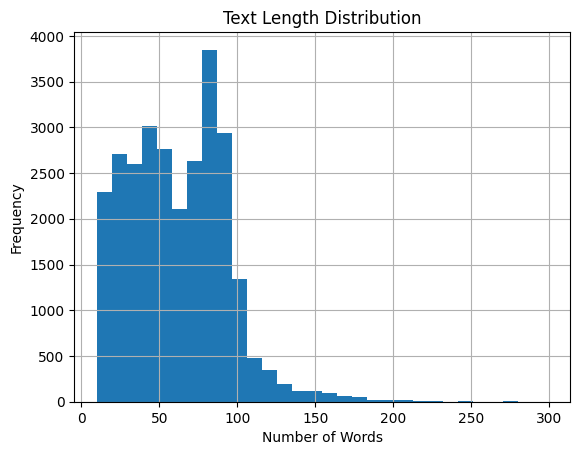

In [ ]:
import matplotlib.pyplot as plt
# recreate clean text
a['clean_text'] = a['issue_description'].apply(clean_text)

# create text length column
a['text_length'] = a['clean_text'].apply(
    lambda x: len(str(x).split())
)

# plot histogram
a['text_length'].hist(bins=30)

plt.title("Text Length Distribution")

plt.xlabel("Number of Words")

plt.ylabel("Frequency")

plt.show()

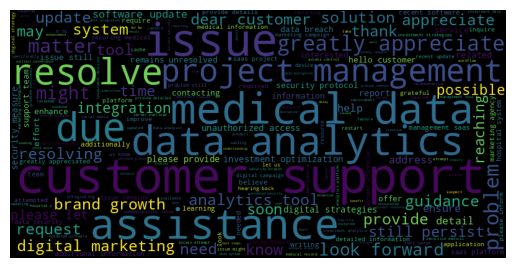

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(a['clean_text'])

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [ ]:
a.value_counts("queue")

,count
queue,
Technical & System Support,12383
Product & Customer Support,10624
Account & Billing Support,4774


In [ ]:
mapping = {

    "Technical Support":
        "Technical & System Support",

    "IT Support":
        "Technical & System Support",

    "Service Outages and Maintenance":
        "Technical & System Support",

    "Product Support":
        "Product & Customer Support",

    "Customer Service":
        "Product & Customer Support",

    "General Inquiry":
        "Product & Customer Support",

    "Sales and Pre-Sales":
        "Product & Customer Support",

    "Billing and Payments":
        "Account & Billing Support",

    "Returns and Exchanges":
        "Account & Billing Support",

    "Human Resources":
        "Account & Billing Support"
}

In [ ]:
a["queue"] = a["queue"].replace(mapping)

/tmp/ipykernel_6342/2979593631.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a["queue"] = a["queue"].replace(mapping)


In [ ]:
print(a["queue"].value_counts())

queue
Technical & System Support    12383
Product & Customer Support    10624
Account & Billing Support      4774
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

# =====================================
# CREATE SEPARATE ENCODERS
# =====================================

type_label_encoder = LabelEncoder()

queue_label_encoder = LabelEncoder()

priority_label_encoder = LabelEncoder()

# =====================================
# ENCODE COLUMNS
# =====================================

a['type_encoded'] = type_label_encoder.fit_transform(
    a['type']
)

a['queue_encoded'] = queue_label_encoder.fit_transform(
    a['queue']
)

a['priority_encoded'] = priority_label_encoder.fit_transform(
    a['priority']
)

# =====================================
# DISPLAY
# =====================================

display(a.head())

/tmp/ipykernel_6342/97928962.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a['type_encoded'] = type_label_encoder.fit_transform(
/tmp/ipykernel_6342/97928962.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a['queue_encoded'] = queue_label_encoder.fit_transform(
/tmp/ipykernel_6342/97928962.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.

,type,queue,priority,issue_description,clean_text,text_length,type_encoded,queue_encoded,priority_encoded
1,Incident,Technical & System Support,high,"Account Disruption Dear Customer Support Team,...",account disruption dear customer support team ...,88,1,2,0
2,Request,Account & Billing Support,medium,Query About Smart Home System Integration Feat...,query about smart home system integration feat...,87,3,0,2
3,Request,Account & Billing Support,low,Inquiry Regarding Invoice Details Dear Custome...,inquiry regarding invoice details dear custome...,101,3,0,1
4,Problem,Product & Customer Support,medium,Question About Marketing Agency Software Compa...,question about marketing agency software compa...,107,2,1,2
5,Request,Technical & System Support,high,"Feature Query Dear Customer Support,\n\nI hope...",feature query dear customer support n ni hope ...,105,3,2,0


In [151]:
x=a[["issue_description"]]
y=a[["queue_encoded"]]

In [150]:
x

,issue_description
1,"Account Disruption Dear Customer Support Team,..."
2,Query About Smart Home System Integration Feat...
3,Inquiry Regarding Invoice Details Dear Custome...
4,Question About Marketing Agency Software Compa...
5,"Feature Query Dear Customer Support,\n\nI hope..."
...,...
61757,Guidelines for Securing Medical Data in OBS St...
61758,Can you provide information on digital strate...
61759,Support for Marketing Enhancements Request for...
61760,Assistance Needed for IFTTT Docker Integration...


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)
tokenizer.fit_on_texts(X_train['issue_description'])

In [ ]:
X_train_seq = tokenizer.texts_to_sequences(X_train['issue_description'])
X_test_seq = tokenizer.texts_to_sequences(X_test['issue_description'])

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_length = 200

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding='post'
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout
)

model = Sequential([

    Embedding(
        input_dim=10000,
        output_dim=128,
        input_length=max_length
    ),

    LSTM(64),

    Dropout(0.5),

    Dense(32, activation='relu'),

    Dense(5, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
556/556 ━━━━━━━━━━━━━━━━━━━━ 27s 48ms/step - accuracy: 0.4443 - loss: 1.0306 - val_accuracy: 0.4497 - val_loss: 1.0338
Epoch 2/10
556/556 ━━━━━━━━━━━━━━━━━━━━ 26s 47ms/step - accuracy: 0.4439 - loss: 1.0308 - val_accuracy: 0.4497 - val_loss: 1.0327
Epoch 3/10
556/556 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - accuracy: 0.4445 - loss: 1.0301 - val_accuracy: 0.4490 - val_loss: 1.0330
Epoch 4/10
556/556 ━━━━━━━━━━━━━━━━━━━━ 17s 30ms/step - accuracy: 0.4455 - loss: 1.0303 - val_accuracy: 0.4497 - val_loss: 1.0329
Epoch 5/10
556/556 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.4452 - loss: 1.0297 - val_accuracy: 0.4497 - val_loss: 1.0327
Epoch 6/10
556/556 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.4452 - loss: 1.0295 - val_accuracy: 0.4488 - val_loss: 1.0332
Epoch 7/10
556/556 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.4452 - loss: 1.0295 - val_accuracy: 0.4490 - val_loss: 1.0340
Epoch 8/10
556/556 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.4451 - loss: 1.0297 - val

In [ ]:
loss, accuracy = model.evaluate(
    X_test_pad,
    y_test
)

print("Accuracy:", accuracy)

174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4461 - loss: 1.0317
Accuracy: 0.4461040198802948


In [ ]:
import pandas as pd
import numpy as np
import re
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer
)

from datasets import Dataset

In [ ]:
train_df = pd.DataFrame({
    "text": X_train["issue_description"],
    "label": y_train["queue_encoded"]
})

test_df = pd.DataFrame({
    "text": X_test["issue_description"],
    "label": y_test["queue_encoded"]
})

train_df.head()

,text,label
52472,Urgent: Unforeseen Server Failures Need Your P...,0
15837,"Support for Boosting Brand Visibility Hi, coul...",2
7051,Customer support has received a report regard...,2
56483,Technical Problem with Marketing Site Customer...,2
45286,Support for Hospital Issues There has been a s...,0


In [ ]:
train_dataset = Dataset.from_pandas(train_df)

test_dataset = Dataset.from_pandas(test_df)

In [ ]:
tokenizer = DistilBertTokenizerFast.from_pretrained(
    "distilbert-base-uncased"
)

In [ ]:
def tokenize(batch):

    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

In [ ]:
train_dataset = train_dataset.map(
    tokenize,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize,
    batched=True
)

Map:   0%|          | 0/22224 [00:00<?, ? examples/s]

Map:   0%|          | 0/5557 [00:00<?, ? examples/s]

In [ ]:
train_dataset = train_dataset.remove_columns(["text"])

test_dataset = test_dataset.remove_columns(["text"])

In [ ]:
train_dataset.set_format("torch")

test_dataset.set_format("torch")

In [ ]:
num_labels = a['queue_encoded'].nunique()

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.01,

    logging_steps=50,

    report_to="none",

    load_best_model_at_end=True,
    metric_for_best_model="f1",      # or "accuracy"
    greater_is_better=True,
)

In [ ]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(
        labels,
        predictions
    )

    precision = precision_score(
        labels,
        predictions,
        average='weighted',
        zero_division=0
    )

    recall = recall_score(
        labels,
        predictions,
        average='weighted',
        zero_division=0
    )

    f1 = f1_score(
        labels,
        predictions,
        average='weighted',
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train['priority_encoded']),
    y=y_train['priority_encoded']
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float
)

print(class_weights)

tensor([0.8636, 1.6288, 0.8142])


In [ ]:
from transformers import Trainer, EarlyStoppingCallback
from torch.nn import CrossEntropyLoss

class WeightedTrainer(Trainer):

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None # Add this parameter
    ):

        labels = inputs.get("labels")

        outputs = model(**inputs)

        logits = outputs.get("logits")

        loss_fct = CrossEntropyLoss(
            weight=class_weights.to(model.device)
        )

        loss = loss_fct(
            logits,
            labels
        )

        return (
            (loss, outputs)
            if return_outputs
            else loss
        )


In [ ]:
trainer = WeightedTrainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,

    compute_metrics=compute_metrics,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.031500,0.989022,0.481555,0.508309,0.481555,0.485003
2,0.849600,0.887577,0.561994,0.581549,0.561994,0.563804
3,0.661100,0.812402,0.637574,0.648829,0.637574,0.638407
4,0.485600,0.787889,0.705597,0.710801,0.705597,0.706078
5,0.342700,0.792782,0.735289,0.735882,0.735289,0.735354
6,0.326100,0.815684,0.756163,0.755741,0.756163,0.755514
7,0.177200,1.006428,0.768580,0.770811,0.768580,0.768152
8,0.181300,1.054182,0.775058,0.775602,0.775058,0.775013
9,0.164500,1.158103,0.777578,0.778019,0.777578,0.777033


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.031500,0.989022,0.481555,0.508309,0.481555,0.485003
2,0.849600,0.887577,0.561994,0.581549,0.561994,0.563804
3,0.661100,0.812402,0.637574,0.648829,0.637574,0.638407
4,0.485600,0.787889,0.705597,0.710801,0.705597,0.706078
5,0.342700,0.792782,0.735289,0.735882,0.735289,0.735354
6,0.326100,0.815684,0.756163,0.755741,0.756163,0.755514
7,0.177200,1.006428,0.768580,0.770811,0.768580,0.768152
8,0.181300,1.054182,0.775058,0.775602,0.775058,0.775013
9,0.164500,1.158103,0.777578,0.778019,0.777578,0.777033
10,0.098300,1.252123,0.783696,0.786132,0.783696,0.783157


TrainOutput(global_step=13890, training_loss=0.4479559433382994, metrics={'train_runtime': 2925.637, 'train_samples_per_second': 75.963, 'train_steps_per_second': 4.748, 'total_flos': 7360019922493440.0, 'train_loss': 0.4479559433382994, 'epoch': 10.0})

In [ ]:
results = trainer.evaluate()
print(results)

In [154]:
model.save_pretrained("priority_classifier_files")
tokenizer.save_pretrained("priority_classifier_files")

('priority_classifier_files/tokenizer_config.json',
 'priority_classifier_files/special_tokens_map.json',
 'priority_classifier_files/vocab.txt',
 'priority_classifier_files/added_tokens.json',
 'priority_classifier_files/tokenizer.json')

In [155]:
import pickle

with open("priority_label_encoder.pkl", "wb") as f:
    pickle.dump(priority_label_encoder, f)

In [ ]:
import shutil

shutil.make_archive(
    "priority_classifier_files",
    'zip',
    "priority_classifier_files"
)

'/content/priority_classifier_files.zip'

In [156]:
from google.colab import files


files.download("priority_label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("priority_classifier_files.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>